# Imports

In [1]:
%load_ext autoreload
%autoreload 2
    
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import random
from math import sqrt
from sklearn.metrics import mean_squared_error
from DataHandler import DataLoader, DataPreparation, Reader
from Model import Model
from Utils import boxplot, plot_predictions, plot_prediction_sequence, plot_single_prediction
from Pipeline import Pipeline

np.set_printoptions(suppress=True)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

2024-09-25 14:44:18.191588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-25 14:44:18.199568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-25 14:44:18.210140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-25 14:44:18.213309: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-25 14:44:18.221006: I tensorflow/core/platform/cpu_feature_guar

# Load Data

In [2]:
loader = DataLoader("amerigo.xlsx")
loader.slice_data("Data", 44212, 44527)
loader.handle_na()

In [3]:
data = loader.data.copy()
data.drop(['Data', 'Ora Solare', 'Turbidity [FNU]', 'Pioggia Fit [mm]'], axis=1, inplace=True)
data.set_index("Data + Ora Solare", inplace = True)

In [4]:
# data.describe().transpose()

# Data Preparation

In [106]:
timesteps_in = 120
timesteps_out = 24
train_X, train_y, test_X, test_y = DataPreparation.create_dataset(
    data, 
    "DOC formula", 
    5000, 
    timesteps_in=timesteps_in, 
    timesteps_out=timesteps_out
)
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(5000, 120, 10) (5000, 24) (1947, 120, 10) (1947, 24)


# Model

In [107]:
input_shape = (train_X.shape[1], train_X.shape[2])
model = Model(input_shape, output=timesteps_out)

In [108]:
history = model.fit(train_X, train_y, validation_data=(test_X, test_y))

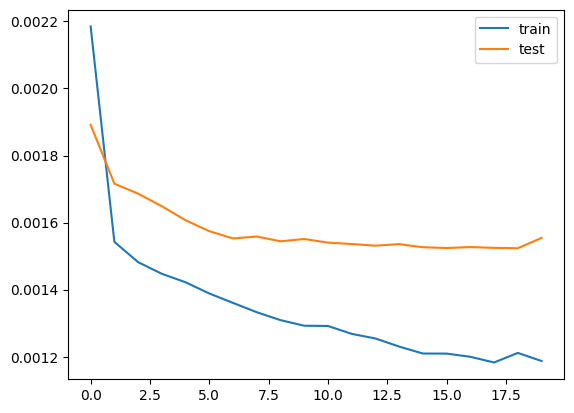

In [109]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# Predictions

In [110]:
yhat = model.predict(test_X)
yhat = DataPreparation.inverse_transform_y(yhat, test_X.shape[2])

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [112]:
real_y = DataPreparation.inverse_transform_y(test_y, test_X.shape[2])

In [113]:
rmse = sqrt(mean_squared_error(real_y, yhat))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 1.176


In [117]:
plot_predictions(real_y, yhat)

Sequence prediction for the whole dataset is not available


# Outliers

In [13]:
loader.data.describe()

,Data,Ora Solare,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit
count,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000,7090.000000
mean,44365.813258,0.478773,44366.292031,15.785097,36.899455,15.543209,1.797400,0.152959,0.274879,0.103893,17.570931,66.606065,995.741319,210.225639,3.137243
std,88.513111,0.289304,88.514412,6.478164,169.111344,4.739380,1.164533,0.334799,0.093475,0.638528,8.565663,22.598599,5.339044,302.817354,2.793378
min,44213.000000,0.000000,44213.000000,-3.843333,0.951667,6.020333,0.602878,0.002397,0.130000,0.000000,-5.500000,14.000000,976.900000,0.000000,0.000000
25%,44290.000000,0.208333,44290.260417,10.281667,3.095417,11.411250,1.330089,0.022274,0.210000,0.000000,11.600000,49.000000,992.600000,0.000000,1.400000
50%,44365.000000,0.458333,44365.187500,15.129167,5.222500,15.279417,1.641848,0.060111,0.260000,0.000000,17.100000,67.000000,995.400000,0.000000,2.100000
75%,44439.000000,0.750000,44439.031250,19.713517,12.087500,19.453958,1.852931,0.136157,0.310000,0.000000,23.700000,88.000000,998.400000,387.000000,4.100000
max,44526.000000,0.958333,44526.000000,48.988333,2984.770000,26.725500,30.404323,6.795935,1.650000,18.000000,42.500000,100.000000,1013.400000,1141.000000,19.900000


check outliers and try to predict DOC without outliers

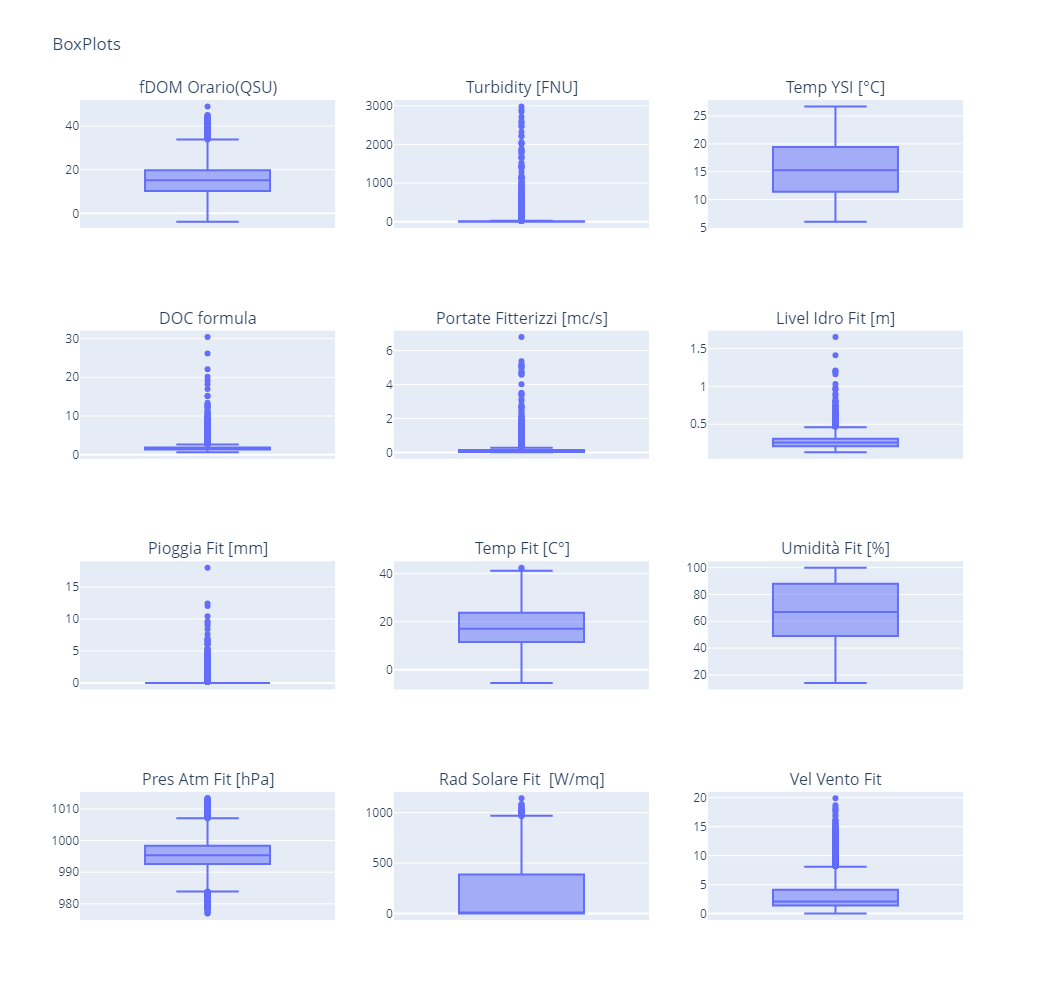

In [18]:
boxplot(loader.data, loader.data.columns[3:])

In [14]:
loader.data.columns

Index(['Data', 'Ora Solare', 'Data + Ora Solare', 'fDOM Orario(QSU)',
       'Turbidity [FNU]', 'Temp YSI [°C]', 'DOC formula',
       'Portate Fitterizzi [mc/s]', 'Livel Idro Fit [m]', 'Pioggia Fit [mm]',
       'Temp Fit [C°]', 'Umidità Fit [%]', 'Pres Atm Fit [hPa]',
       'Rad Solare Fit  [W/mq]', 'Vel Vento Fit'],
      dtype='object')

In [165]:
def find_outliers_IQR(df):
   q1=df.quantile(0.25)
   q3=df.quantile(0.75)
   IQR=q3-q1
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
   return outliers

In [170]:
outliers = find_outliers_IQR(loader.data['Pioggia Fit [mm]'])

In [171]:
outliers.describe()

count    480.000000
mean       1.534583
std        1.958050
min        0.200000
25%        0.200000
50%        0.800000
75%        2.000000
max       18.000000
Name: Pioggia Fit [mm], dtype: float64

In [172]:
len(outliers)

480

In [169]:
len(loader.data)

7090

In [30]:
outliers.isna().sum()

Data                         7090
Ora Solare                   7090
Data + Ora Solare            7090
fDOM Orario(QSU)             6973
Turbidity [FNU]              5836
Temp YSI [°C]                7090
DOC formula                  6710
Portate Fitterizzi [mc/s]    6257
Livel Idro Fit [m]           6860
Pioggia Fit [mm]             6610
Temp Fit [C°]                7088
Umidità Fit [%]              7090
Pres Atm Fit [hPa]           6712
Rad Solare Fit  [W/mq]       7006
Vel Vento Fit                6549
dtype: int64

# Pipeline 

In [4]:
pipeline = Pipeline('Fitterizzi_output.csv', "Meteo Agosto 22 - Luglio 23.xlsx")

In [5]:
pipeline.load_files()

In [6]:
pipeline.slice_data()

In [7]:
pipeline.add_doc_formula_values()

In [8]:
pipeline.handle_missing_values()

In [9]:
pipeline.drop_columns()

In [10]:
pipeline.merge_data_sources()

In [11]:
pipeline.align_start_date()

In [135]:
pipeline.create_dataset(timesteps_out=24)

In [56]:
pipeline.create_model(output=1)

In [57]:
pipeline.train_model(plot=False)

Epoch 1/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0024 - val_loss: 4.1518e-04
Epoch 2/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0013 - val_loss: 4.0192e-04
Epoch 3/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0014 - val_loss: 4.1816e-04
Epoch 4/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0013 - val_loss: 3.9879e-04
Epoch 5/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0012 - val_loss: 3.6571e-04
Epoch 6/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0012 - val_loss: 3.3589e-04
Epoch 7/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.8642e-04 - val_loss: 3.8353e-04
Epoch 8/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0010 - val_loss: 3.2735e-04
Epoch 9/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 8.3515e-04 - val_loss: 2.8671e-04
Epoch 10/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 8.1858e-04 - val_loss: 2.5535e-04
Epoch 11/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 7.3141e-04 - val_loss:

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test RMSE: 0.379


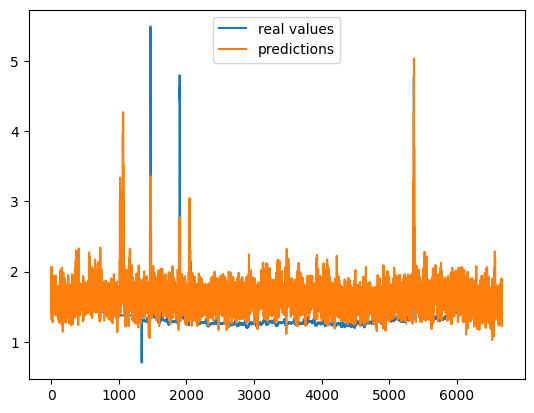

In [115]:
pipeline.evaluate_model(plot=True)

# Trash

In [ ]:
input_shape = (train_X.shape[1], train_X.shape[2])
model_test = Model(input_shape, output=timesteps_out)
history_test = model_test.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=10)
plt.plot(history_test.history['loss'], label='train')
plt.plot(history_test.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
X_values = test_X[0, :]
Y_values = test_y[0]

In [ ]:
n_columns = X_values.shape[1]
p = model_test.predict(X_values, DataPreparation.scaler)
real = DataPreparation.inverse_transform_y(p, n_columns)
predictions = real.reshape(real.shape[1])
rescaled_past_values = DataPreparation.inverse_transform_y(X_values[:,0].reshape(1, X_values.shape[0]), n_columns)
rescaled_past_values = rescaled_past_values[0,:]
rescaled_future_values = DataPreparation.inverse_transform_y(Y_values.reshape(1, Y_values.shape[0]), n_columns)
rescaled_future_values = rescaled_future_values[0,:]

In [ ]:
plot_prediction_sequence(predictions, rescaled_past_values, rescaled_future_values)

In [ ]:
rmse = sqrt(mean_squared_error(real_future, pred))
print('Test RMSE: %.3f' % rmse)

In [297]:
# np.concatenate((train_X[:2], train_X[2:4]), axis=0) == train_X[:4]

In [135]:
all_data_X = np.concatenate((pipeline.train_X, pipeline.validation_X, pipeline.test_X), axis=0)
all_data_y = np.concatenate((pipeline.train_y, pipeline.validation_y, pipeline.test_y), axis=0)


yhat = pipeline.model.predict(pipeline.validation_X)
yhat = DataPreparation.inverse_transform_y(yhat, pipeline.validation_X.shape[2])
real_y = DataPreparation.inverse_transform_y(pipeline.validation_y, pipeline.validation_X.shape[2])

rmse = sqrt(mean_squared_error(real_y, yhat))
print('Test RMSE: %.3f' % rmse)
# plt.plot(real_y, label='real values')
# plt.plot(yhat, label='predictions')
# plt.legend()
# plt.show()  

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test RMSE: 0.600


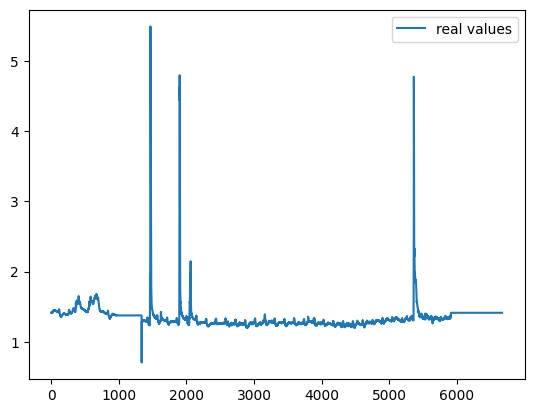

In [223]:
plt.plot(pipeline.merged_data["DOC formula"].values[-pipeline.test_y.shape[0]:], label='real values')
plt.legend()
plt.show()  

In [368]:
pipeline.train_X.shape

(26710, 24, 11)

In [108]:
pipeline.merged_data.columns

Index(['DOC formula', 'fDOM QSU', 'Turbidity FNU', 'TSS mg/L', 'pH', 'Temp °C',
       'Pioggia (mm)', 'Livello idrometrico (m)', 'Pressione hPa',
       'Radiazione solare W/mq', 'Temperatura (°C)', 'Umidità (%)',
       'Velocità vento (m/s)'],
      dtype='object')

In [109]:
data.columns

Index(['DOC formula', 'fDOM Orario(QSU)', 'Temp YSI [°C]',
       'Portate Fitterizzi [mc/s]', 'Livel Idro Fit [m]', 'Temp Fit [C°]',
       'Umidità Fit [%]', 'Pres Atm Fit [hPa]', 'Rad Solare Fit  [W/mq]',
       'Vel Vento Fit'],
      dtype='object')

In [329]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Lambda, Dropout

# Hyperparameter Tuning

In [137]:
pipeline.hyperparameter_tunning(epochs=5, max_trials=3, executions_per_trial=2)

Trial 3 Complete [00h 00m 25s]
mse: 0.0013834882411174476

Best mse So Far: 0.0013834882411174476
Total elapsed time: 00h 01m 29s


/home/luis/.local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [138]:
pipeline.best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 32)         │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,326 (380.18 KB)

 Trainable params: 97,326 (380.18 KB)

 Non-trainable params: 0 (0.00 B)

In [140]:
yhat = pipeline.best_model.predict(pipeline.test_X)
yhat = DataPreparation.inverse_transform_y(yhat, pipeline.test_X.shape[2])
real_y = DataPreparation.inverse_transform_y(pipeline.test_y, pipeline.test_X.shape[2])

rmse = sqrt(mean_squared_error(real_y, yhat))
print('Test RMSE: %.3f' % rmse)
plot_predictions(real_y, yhat)

208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(6655, 24)
Test RMSE: 0.785
Plotting sequence prediction for the whole dataset is not available
